<h1 style="text-align: center; font-family: Arial; font-weight: bold; color:green; font-size:36px;">Indigenous Energy Forecasting</h1>

In [3]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Time Series Analysis
from statsmodels.tsa.seasonal import seasonal_decompose

# Scaler and Score Metrics
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

# Neural Network
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping


In [4]:
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [5]:
#pip install pmdarima
#!pip install scikeras

### Custom Functions

In [304]:
def generate_pie_chart(data, start, end, columns, title): 
    
    # Filter data by year, providing start and end year
    filtered_data = ie_power_production_df.loc[(ie_power_production_df.Year > start) & (ie_power_production_df.Year<end)]
    
    # Group by Year
    yearly_data = filtered_data.groupby('Year')[columns].sum().reset_index()

    # Add the total renewable energy production for each year
    yearly_data['Total'] = yearly_data[columns].sum(axis=1)
    
    # Create subplots
    fig = make_subplots(
        rows=1, cols=len(yearly_data),
        specs=[[{'type':'domain'}]*len(yearly_data)],
        subplot_titles=[str(year) for year in yearly_data['Year']]
    )
    
    # Loop by yearly data
    for idx, row in yearly_data.iterrows():
        fig.add_trace(
            go.Pie(
                labels=columns,  # use correct column labels
                values=[row[col] for col in columns],  # pick values for that row
                name=str(row['Year']),
                hole=0.4,
                textinfo='label+percent',  
                hoverinfo='label+percent+value',  
                title=f"Total: {row['Total']:.2f} ktoe"
            ),
            row=1, 
            col=idx+1  # index is 0-based, subplot cols start at 1
        )
    # Update Titles 
    fig.update_layout(title_text=title, height=500)

    #Render Graph
    fig.show()

def decompose(data):
    # Decompose data
    result = seasonal_decompose(data, model='additive')
    
    # Create subplots
    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=False)
    
    # Plot Observed 
    sns.lineplot(
        x=result.observed.index, 
        y=result.observed.values, 
        ax=axes[0],
        color='navy'
    )
    axes[0].set_title('Observed', loc='left')
    
    # Plot Trend
    sns.lineplot(
        x=result.trend.index, 
        y=result.trend.values, 
        ax=axes[1],
        color='green'
    )
    axes[1].set_title('Trend', loc='left')
    
    # Plot Seasonal
    sns.lineplot(
        x=result.seasonal.index, 
        y=result.seasonal.values, 
        ax=axes[2],
        color='orange'
    )
    axes[2].set_title('Seasonality', loc='left')
    
    # Plot Residuals
    sns.scatterplot(
        x=result.resid.index, 
        y=result.resid.values, 
        ax=axes[3],
        color='crimson',
        s=30  # Size of dots
    )
    axes[3].set_title('Residuals', loc='left')
    
    plt.tight_layout()
    plt.show()

# Create a function to return rows containing outliers using IQR
def check_outliers(data, feature_name):
    # Calculate the 25th and 75th percentiles
    Q1 = np.percentile(data[feature_name], 25)
    Q3 = np.percentile(data[feature_name], 75)
    # Calculate for IQR 
    IQR = Q3 - Q1
    
    # Define the lower and upper bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR 
    
    # Return records where the feature value is below the lower bound or above the upper bound
    outliers = data.loc[(data[feature_name] < lower_bound) | (data[feature_name] > upper_bound)]
    return outliers

def transform_right_skewed(data):
    #Create a variable to store the results of the testing
    transformation_df = pd.DataFrame()
    
    # Apply transformations
    transformation_df['original']=data
    transformation_df['log'] = np.log(data + 1)  # Avoid log(0)
    transformation_df['square'] = np.square(data)
    transformation_df['cbrt'] = np.cbrt(data)
    
    # Create 2 x 2 subplots 
    fig, axes = plt.subplots(2, 2, figsize=(10, 6))
    
    # Log Transformation
    sns.histplot(data=transformation_df, x='original', kde=True, bins=10, ax=axes[0, 0], color='skyblue')
    axes[0, 0].set_title('Original')
    
    # Log Transformation
    sns.histplot(data=transformation_df, x='log', kde=True, bins=10, ax=axes[0, 1], color='skyblue')
    axes[0, 1].set_title('Distribution Plot: Log Transform')
    
    # Square Transformation
    sns.histplot(data=transformation_df, x='square', kde=True, bins=10, ax=axes[1, 0], color='skyblue')
    axes[1, 0].set_title('Distribution Plot: Square')
    
    # Cube Root Transformation
    sns.histplot(data=transformation_df, x='cbrt', kde=True, bins=10, ax=axes[1, 1], color='skyblue')
    axes[1, 1].set_title('Distribution Plot: Cube Root')

    plt.tight_layout()
    plt.show()

    # Return values
    return transformation_df



def add_features(dataframe):
   seasons = {
    'winter':[12, 1, 2],
    'spring':[3, 4, 5],
    'summer':[6, 7, 8],
    'autumn':[9,10,11],
    'start_month':[1],
    'end_month':[12]  
   }
    
   for season, months in seasons.items():
        dataframe[season] = dataframe['Month_Numeric'].isin(months).astype(int)
       
   return dataframe

# Create lag features
def generate_lag_features(data, n_lags):
    lags_df = pd.DataFrame(data)
    for lag in range(1, n_lags + 1):
        lags_df[f'lag_{lag}'] = data.shift(lag)
    lags_df.dropna(inplace=True)
    return lags_df

# Calculate metrics for machine learning results
def calculate_metrics(data, pred_data):
    mse = mean_squared_error(data, pred_data)
    r2 = r2_score(data, pred_data)
    return r2, mse


# Plot Measure of Central Tendency, variance, and standard deviation
# data - dataframe feature
# title - title of the graph
def plot_central_tendency(df, column, ax):
    data = df[column]

    # Calculate for mean, median, mode, std, and variance
    mean_val = data.mean()
    median_val = data.median()
    mode_val = data.mode().iloc[0]
    variance = np.var(data,  ddof=1)
    std = np.std(data)  

    # Plot histogram
    sns.histplot(data=df, x=column, kde=True, color='skyblue', bins=20, ax=ax)

    ax.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    ax.axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.2f}')
    ax.axvline(mode_val, color='purple', linestyle='--', label=f'Mode: {mode_val:.2f}')

    ax.set_title(f' Measure of Central Tendency of {column},\n Variance:{variance:.2f}, Standard Deviation: {std:.2f}')
    ax.set_xlabel(column)
    ax.set_ylabel('Frequency')
    ax.legend()


# Simplify Exporting of Graphs
def export_graph(label='img', graph_type='plt'):
    try:
        plt.savefig(f"./assests/{label}.png", dpi=300, bbox_inches='tight')
        print('Graph exported.')
    except:
        print('There is a error exporting the graph.')

# Check dataframe file size
def check_dataframe_filesize(data):
    size_kb = data.memory_usage(deep=True).sum() / 1024
    return size_kb

total_freed_memory_kb=[]
# Delete a dataframe and check total freed memory
def delete_df(df_name):
    # Find the dataframe in global variables
    if df_name in globals():
        if isinstance(globals()[df_name], pd.DataFrame):
            file_size=check_dataframe_filesize(globals()[df_name])
            del globals()[df_name]
            total_freed_memory_kb.append(file_size)
            print(f'Total freed memory:{sum(total_freed_memory_kb)}kb.')
        else:
            print('Dataframe name does not exist.')
    else:
        print('Dataframe name does not exist.')

## Dataset 

In [260]:
# Import Dataset
ie_power_production_df = pd.read_csv('./Datasets/AA.csv',)

# Show first 5 records
ie_power_production_df=ie_power_production_df.loc[ie_power_production_df['Year of Period']<2025]
ie_power_production_df.head()

,Year of Period,Month of Period,Unit,Coal,Combust. Renew.,Hydro,Natural Gas,Oil,Other,Peat & BM,Solar Farms,Wastes,Wind
1,2024,January,ktoe,8.6,1.1,11.3,113.8,2.4,0.1,3.4,1.5,4.8,98.2
2,2024,February,ktoe,7.4,1.0,9.8,85.3,1.0,0.1,4.6,1.7,4.3,103.0
3,2024,March,ktoe,7.5,1.2,10.0,87.7,0.5,0.1,4.2,3.0,1.9,114.4
4,2024,April,ktoe,7.1,1.1,7.6,92.2,0.4,0.1,4.4,5.6,3.3,79.9
5,2024,May,ktoe,2.1,1.1,3.0,116.1,2.1,0.1,5.1,8.1,4.8,48.2


# 1. Data Preparation & Visualisation

## 1.1 Data Preparation

In [264]:
ie_power_production_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 180 entries, 1 to 180
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year of Period   180 non-null    int64  
 1   Month of Period  180 non-null    object 
 2   Unit             180 non-null    object 
 3   Coal             180 non-null    float64
 4   Combust. Renew.  180 non-null    float64
 5   Hydro            180 non-null    float64
 6   Natural Gas      180 non-null    float64
 7   Oil              180 non-null    float64
 8   Other            180 non-null    float64
 9   Peat & BM        180 non-null    float64
 10  Solar Farms      180 non-null    float64
 11  Wastes           180 non-null    float64
 12  Wind             180 non-null    float64
dtypes: float64(10), int64(1), object(2)
memory usage: 19.7+ KB


### 1.1.1 Null and Duplicates Check

In [267]:
# Check for duplicates
print(f'There are {ie_power_production_df.duplicated().sum()} duplicated values in the dataset.')

There are 0 duplicated values in the dataset.


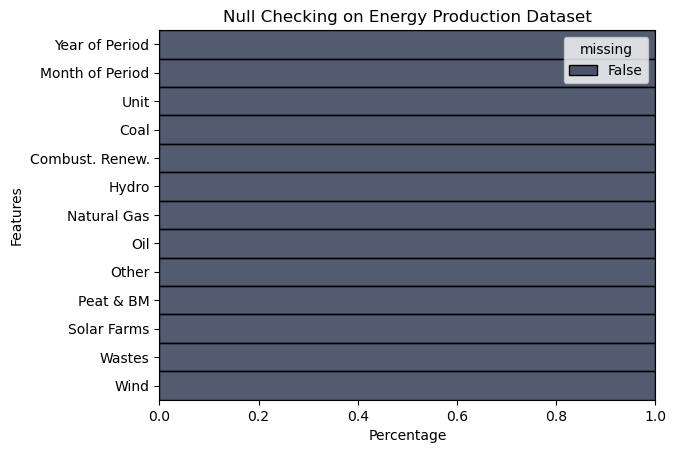

In [269]:
# Set figure pallete
sns.set_palette('cubehelix')

# Plot missing values
sns.histplot(
    data = ie_power_production_df.isnull().melt(value_name='missing'),
    y='variable',
    hue='missing',
    multiple = 'fill'
)

# Display result
plt.title('Null Checking on Energy Production Dataset')
plt.xlabel('Percentage')
plt.ylabel('Features')

# Save figure
# plt.savefig("./assests/null_checking.png", dpi=300, bbox_inches='tight')

plt.show()

Based on the result shown above, there were no missing values present in the dataset.

In [272]:
# Checking for unique values
ie_power_production_df.nunique()

Year of Period      15
Month of Period     12
Unit                 1
Coal               135
Combust. Renew.     10
Hydro               92
Natural Gas        158
Oil                 47
Other               15
Peat & BM          103
Solar Farms         23
Wastes              34
Wind               162
dtype: int64

In [274]:
ie_power_production_df.rename(columns={
    'Year of Period':'Year',
    'Month of Period':'Month',
    'Natural Gas': 'Natural_Gas',
    'Peat & BM': 'Peat_&_BM',
    'Solar Farms': 'Solar_Farms'
}, inplace=True)

In [276]:
try:
    ie_power_production_df.drop(columns=['Unit','Combust. Renew.'], inplace=True)
except:
    print('Error in dropping columns. No changes made.')
    
ie_power_production_df.head()

,Year,Month,Coal,Hydro,Natural_Gas,Oil,Other,Peat_&_BM,Solar_Farms,Wastes,Wind
1,2024,January,8.6,11.3,113.8,2.4,0.1,3.4,1.5,4.8,98.2
2,2024,February,7.4,9.8,85.3,1.0,0.1,4.6,1.7,4.3,103.0
3,2024,March,7.5,10.0,87.7,0.5,0.1,4.2,3.0,1.9,114.4
4,2024,April,7.1,7.6,92.2,0.4,0.1,4.4,5.6,3.3,79.9
5,2024,May,2.1,3.0,116.1,2.1,0.1,5.1,8.1,4.8,48.2


### 1.1.1 Feature Engineering

In [279]:
# Transform Months to Numeric
ie_power_production_df['Month_Numeric'] =  pd.to_datetime(ie_power_production_df['Month'], format='%B').dt.month

# Transform Year and Month to Date
ie_power_production_df['Date'] = pd.to_datetime(ie_power_production_df['Year'].astype(str) + '-' + ie_power_production_df['Month_Numeric'].astype(str).str.zfill(2) + '-01')

# Set Date as Index
ie_power_production_df.set_index('Date', inplace=True)

In [281]:
# Classify Columns to Renewable and Non-Renewable Sources
renewable_energy = ['Hydro', 'Solar_Farms', 'Wastes', 'Wind']
nonrenewable_energy = ['Coal', 'Natural_Gas', 'Oil', 'Peat_&_BM', 'Other']

# Sum all renewable energy sources
ie_power_production_df['Renewable_Energy'] = ie_power_production_df[renewable_energy].sum(axis=1)

# Sum all non-renewable energy sources
ie_power_production_df['Non_Renewable_Energy'] = ie_power_production_df[nonrenewable_energy].sum(axis=1)

# Sort Date in ascending order
ie_power_production_df.sort_index(inplace=True)

# Check dataset if changes have been made 
ie_power_production_df.head()

,Year,Month,Coal,Hydro,Natural_Gas,Oil,Other,Peat_&_BM,Solar_Farms,Wastes,Wind,Month_Numeric,Renewable_Energy,Non_Renewable_Energy
Date,,,,,,,,,,,,,,
2010-01-01,2010,January,34.4,8.3,126.8,6.7,1.7,16.7,0.0,0.0,21.3,1,29.6,186.3
2010-02-01,2010,February,35.0,5.1,120.0,2.5,1.9,16.3,0.0,0.0,13.0,2,18.1,175.7
2010-03-01,2010,March,26.5,2.5,136.8,1.4,1.9,14.8,0.0,0.0,21.6,3,24.1,181.4
2010-04-01,2010,April,20.0,6.3,117.6,1.2,2.0,18.3,0.0,0.0,16.0,4,22.3,159.1
2010-05-01,2010,May,23.3,1.1,116.4,0.6,1.6,15.2,0.0,0.0,14.5,5,15.6,157.1


## 1.2 Data Visualisation

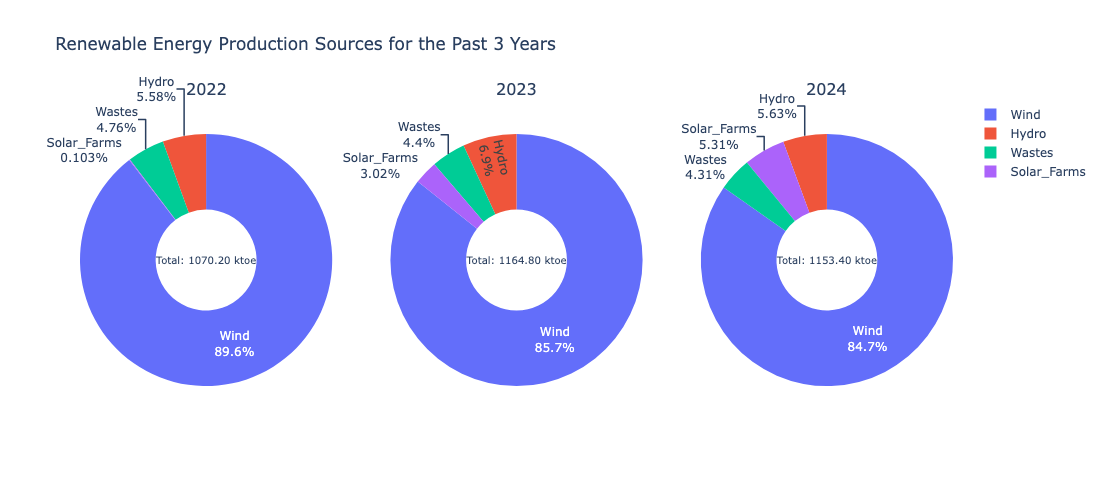

Dataframe name does not exist.


In [300]:
generate_pie_chart(ie_power_production_df, 2021, 2025, renewable_energy, 'Renewable Energy Production Sources for the Past 3 Years')

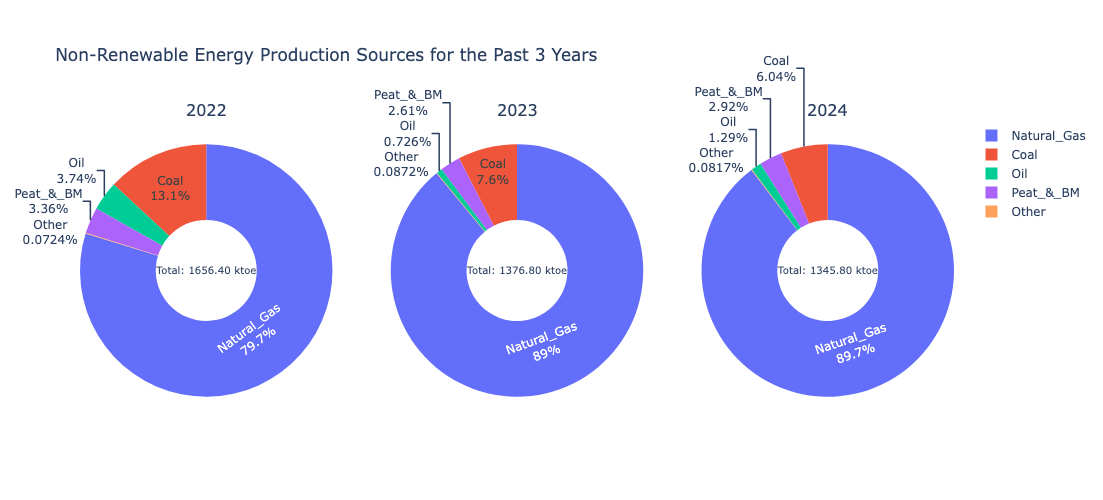

Dataframe name does not exist.


In [302]:
generate_pie_chart(ie_power_production_df, 2021, 2025, nonrenewable_energy, 'Non-Renewable Energy Production Sources for the Past 3 Years')

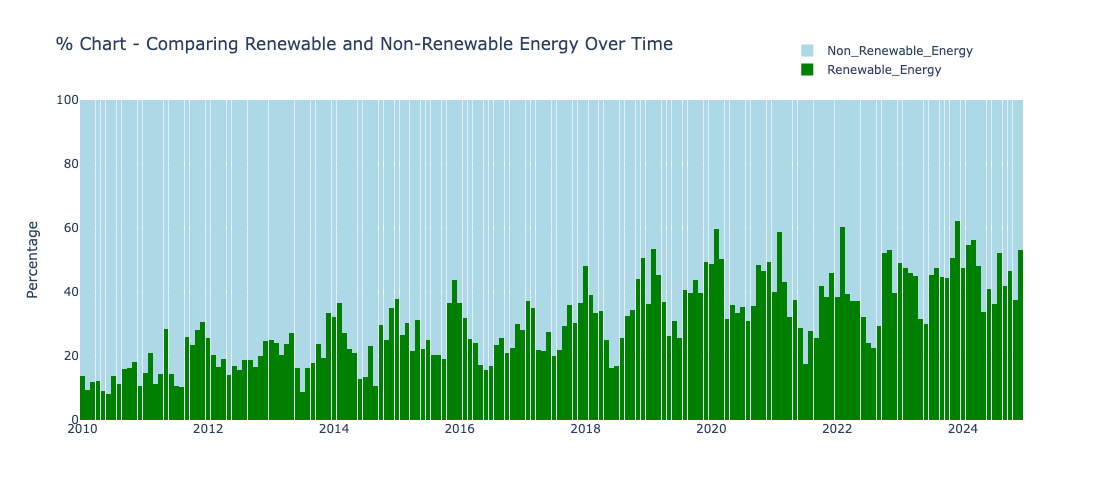

Total freed memory:4.21875kb.


In [306]:
# Convert values to percentages by row
by_energy_group = ie_power_production_df[['Renewable_Energy', 'Non_Renewable_Energy']].copy()
by_energy_group = by_energy_group.div(by_energy_group.sum(axis=1), axis=0) * 100

fig = go.Figure()

# Define custom colors
color_map = {
    'Renewable_Energy': 'green',
    'Non_Renewable_Energy': 'lightblue'
}

for source in by_energy_group:
    fig.add_trace(go.Bar(
        x=by_energy_group.index.astype(str),  
        y=by_energy_group[source],              
        name=source,
        marker_color = color_map[source]
    ))

fig.update_layout(
    barmode='stack',
    bargap=0.02,  
    yaxis=dict(title='Percentage', range=[0, 100]),
    title_text='% Chart - Comparing Renewable and Non-Renewable Energy Over Time',
    legend=dict(
        x=0.75,
        y=1.2,
        xanchor='left', 
        yanchor='top'
    ),
    height=500,
    width=1100
)

fig.update_traces(marker_line_width=0)

fig.show()

#Free up memory
delete_df('by_energy_group')

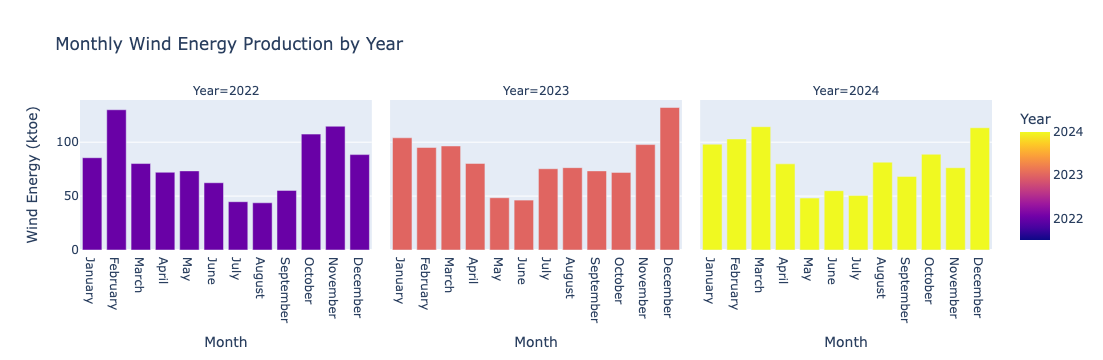

Total freed memory:9.955078125kb.


In [308]:
start_year=2021
end_year=2025
filtered_data=ie_power_production_df.loc[(ie_power_production_df.Year>start_year) & (ie_power_production_df.Year<end_year)]

fig = px.bar(
    filtered_data,
    x='Month',   
    y='Wind',             
    color='Year',         
    barmode='group',      
    facet_col='Year',  
    labels={
        'Month_Numeric':'Month',
        'Wind':'Wind Energy (ktoe)'
    },
    title='Monthly Wind Energy Production by Year',
)

fig.show()

# Free up memory
delete_df('filtered_data')

## 1.3 Exploratory Data Analysis

### 1.3.1 Outlier Checking and Handling

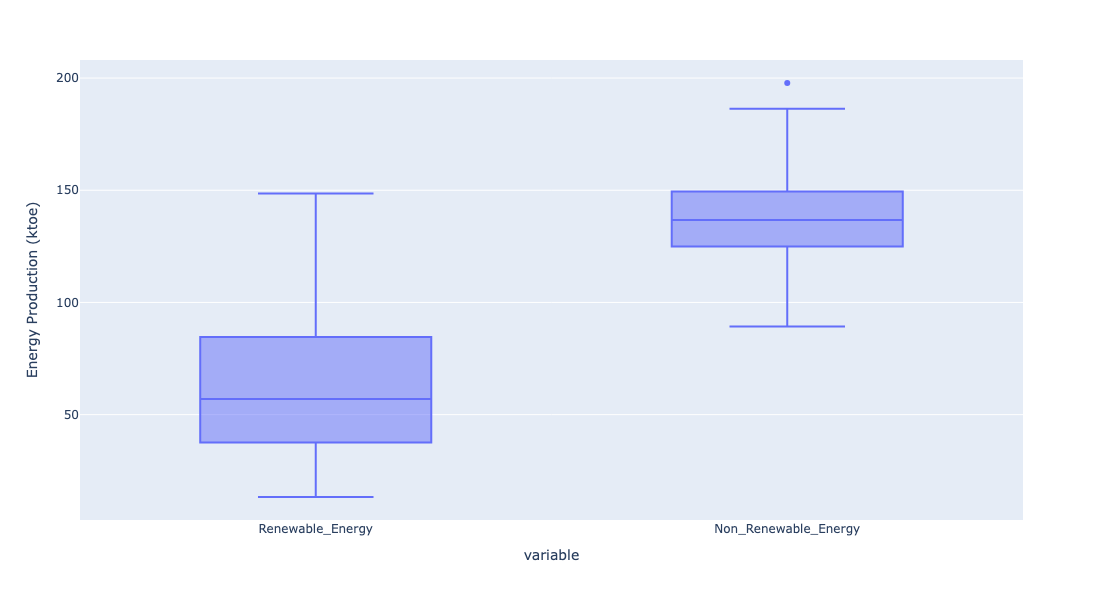

In [294]:
# Plot boxplot to identify outliers
fig = px.box(ie_power_production_df[['Renewable_Energy', 'Non_Renewable_Energy']])

# Set graph size and update y-axis title
fig.update_layout(height=600, 
                  width=600, 
                  yaxis_title='Energy Production (ktoe)')
# Show graph
fig.show()

In [31]:
outliers=check_outliers(ie_power_production_df, 'Non_Renewable_Energy')
outliers.reset_index(inplace=True)
outliers

,Date,Year,Month,Coal,Hydro,Natural_Gas,Oil,Other,Peat_&_BM,Solar_Farms,Wastes,Wind,Month_Numeric,Renewable_Energy,Non_Renewable_Energy
0,2010-01-01,2010,January,34.4,8.3,126.8,6.7,1.7,16.7,0.0,0.0,21.3,1,29.6,186.3
1,2010-12-01,2010,December,36.6,4.4,135.3,6.1,1.8,18.0,0.0,0.0,18.8,12,23.2,197.8


In [32]:
# Replace value with 
ie_power_production_df.loc[outliers.Date,'Non_Renewable_Energy']= np.nan
ie_power_production_df.Non_Renewable_Energy.interpolate(method='linear', limit_direction='both', inplace=True)
ie_power_production_df.loc[outliers.Date.values]

,Year,Month,Coal,Hydro,Natural_Gas,Oil,Other,Peat_&_BM,Solar_Farms,Wastes,Wind,Month_Numeric,Renewable_Energy,Non_Renewable_Energy
Date,,,,,,,,,,,,,,
2010-01-01,2010,January,34.4,8.3,126.8,6.7,1.7,16.7,0.0,0.0,21.3,1,29.6,175.7
2010-12-01,2010,December,36.6,4.4,135.3,6.1,1.8,18.0,0.0,0.0,18.8,12,23.2,176.5


### 1.3.2 Scatterplot with Trend Line

In [35]:
fig = px.scatter(
    ie_power_production_df,
    x=ie_power_production_df.index,
    y='Renewable_Energy',
    trendline='ols', 
    title='Scatterplot with Trendline on Renewable Energy Sources',
    labels={
        'Renewable_Energy': 'Energy (ktoe)'
    }
)

#fig.write_image("./assests/renewable_energy_trend.png")
fig.show()


fig = px.scatter(
    ie_power_production_df,
    x=ie_power_production_df.index,
    y='Non_Renewable_Energy',
    trendline='ols', 
    title='Scatterplot with Trendline on Non-Renewable Energy Sources',
    labels={
        'Non_Renewable_Energy': 'Energy (ktoe)'
    }
)
fig.show()

### 1.3.4

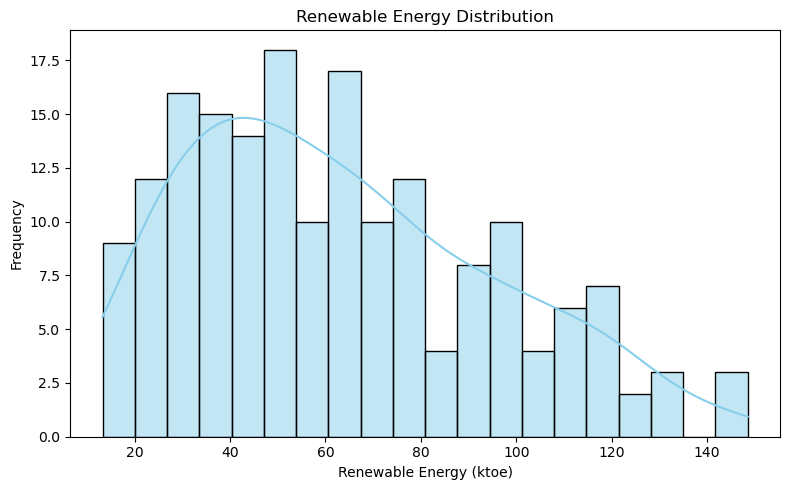

In [39]:
plt.figure(figsize=(8, 5))

# Plot histogram with KDE
sns.histplot(
    ie_power_production_df["Renewable_Energy"],
    kde=True,
    color='skyblue',
    bins=20
)

# Set titles and labels using plt
plt.title('Renewable Energy Distribution')
plt.xlabel('Renewable Energy (ktoe)')
plt.ylabel('Frequency')

# Show plot
plt.tight_layout()
plt.show()

### 1.3.5 Heatmap with Added Feautures

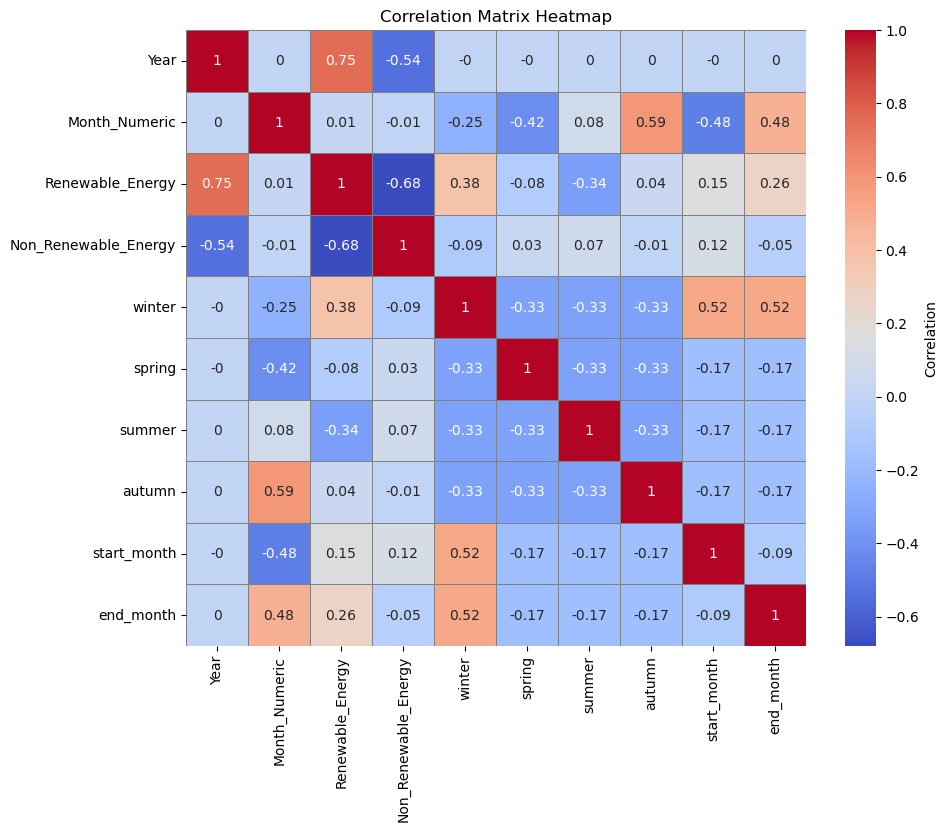

In [41]:
#Add More Features in the Dataset
modeling_data=add_features(ie_power_production_df[['Year', 'Month_Numeric', 'Renewable_Energy', 'Non_Renewable_Energy']])

corr_matrix = modeling_data.corr().round(2)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True,     
    cmap='coolwarm',  
    cbar_kws={'label': 'Correlation'}, 
    linewidths=0.5,  
    linecolor='gray'
)

# Add title and display
plt.title('Correlation Matrix Heatmap')
plt.show()

### 1.3.5 Decomposition of Renewable Energy

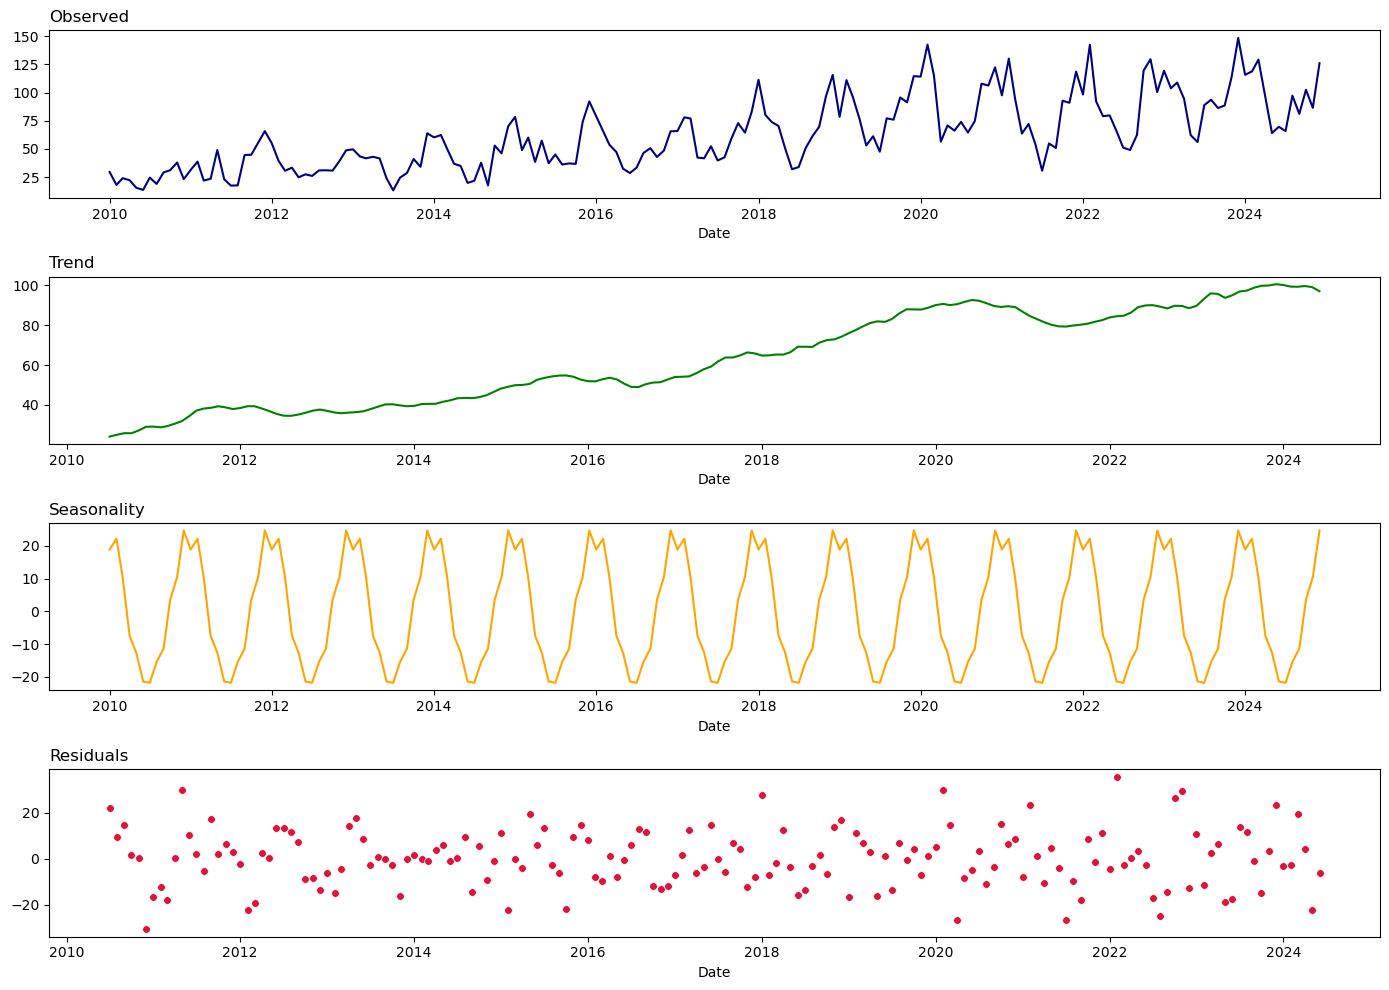

In [43]:
decompose(ie_power_production_df.Renewable_Energy)

# 2. Statistics

## 2.1 Descriptive Statistics

### 2.1.1 Measure of Central Tendency

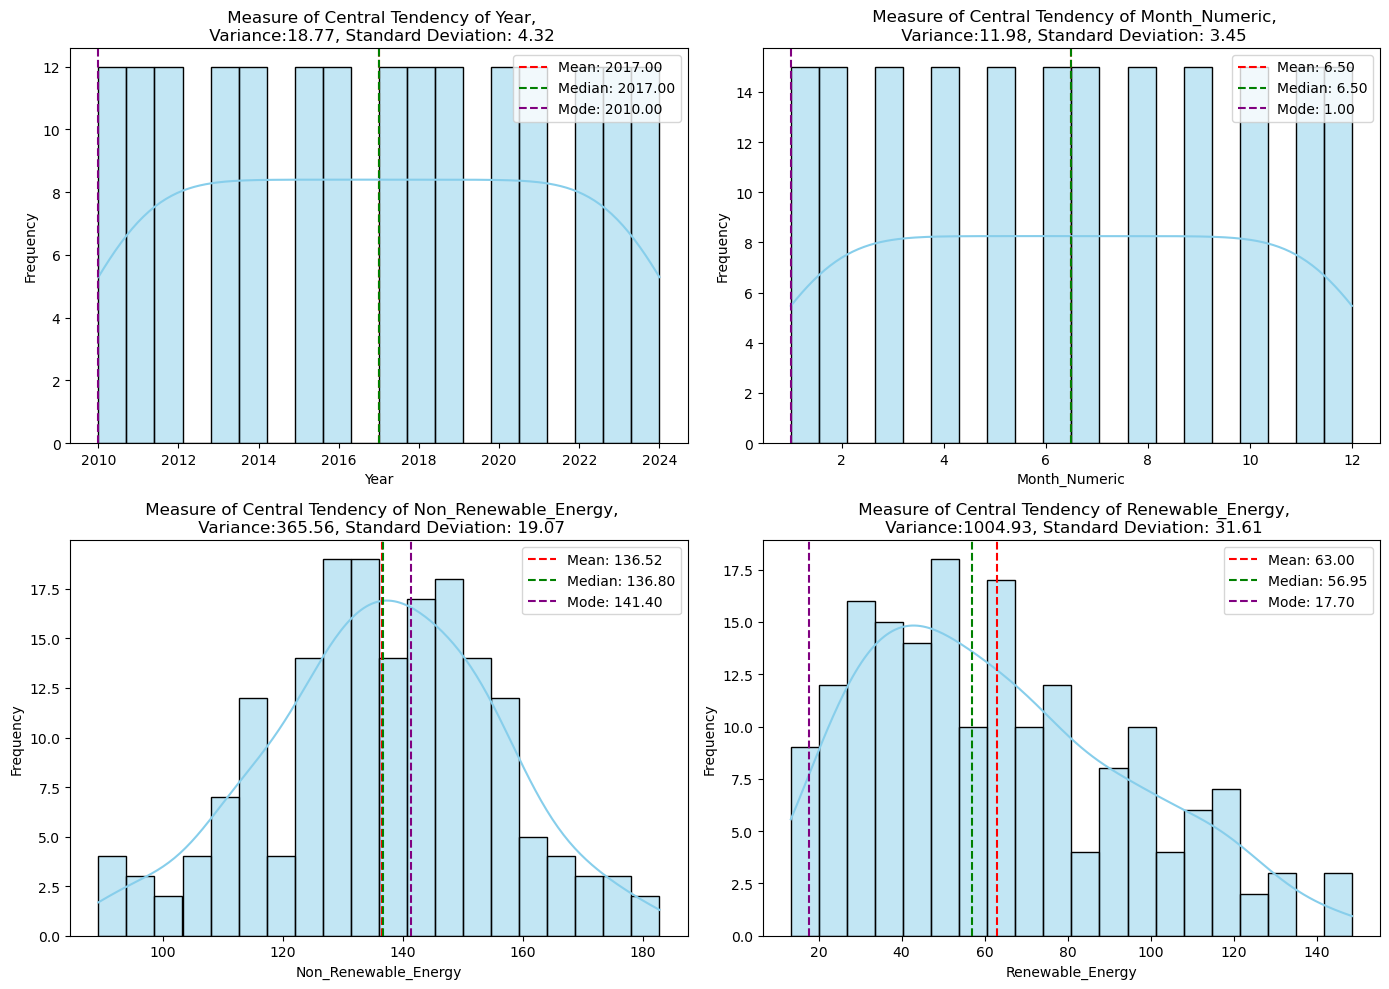

In [47]:
features = ['Year', 'Month_Numeric', 'Non_Renewable_Energy', 'Renewable_Energy']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for index, feature in enumerate(features):
    plot_central_tendency(df=ie_power_production_df, column=feature, ax=axes[index])

plt.tight_layout()
#plt.savefig("./assests/central_t.png", dpi=300, bbox_inches='tight')
plt.show()

Analysis:

Year:
Based on the first graph, the dataset covers from 2010 to 2024. The distribution of the year plot appears to be symmetric or uniform, as supported by the alignment of the mean and the median in 2017. Having a low variance of 18.77 and a standard deviation of 4.32 indicates a consistent distribution of yearly records.

Month Numeric:
	The result shows a symmetric distribution as the mean and median are at 6.5, which indicates that the monthly data are consistent and do not have more than 1 record each month every year. The feature also shows low variance (11.98) and standard deviation (3.45), indicating an even spread of records.

Non-renewable Energy:
	The plot exhibits a nearly normal distribution, having the mean (136.5), median (136.8), and mode (141.4)  close to each other. It also indicates that the non-renewable energy consumption is likely stable since there are no visible spikes or outliers in the graph. A variance of 365.5 suggests that the square deviation of the values is moderate, and the standard deviation of 19.07 denotes that the difference in consumption deviates mostly within +-19 values from the mean.

Renewable Energy:
	There is a significant difference between the mean (63), median (56.95), and the mode (17.70), indicating high variance (1004.93) in the data. The distribution is positively skewed, which suggests that some of the months had very high renewable energy produced. Data should be normalized before proceeding to model training.


### 2.1.2 Transform Data into Normal Distribution 

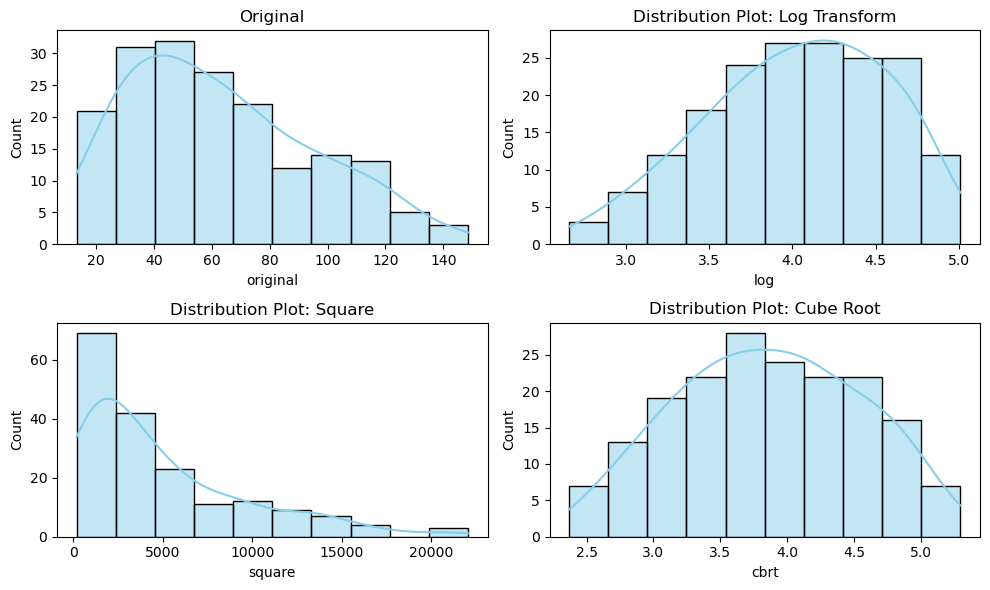

In [50]:
transformed_data=transform_right_skewed(ie_power_production_df.Renewable_Energy)
ie_power_production_df['Renewable_Energy_Transformed'] = transformed_data['cbrt']

### 2.1.3 Boxplot of Renewable Energy

In [52]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Box(
    x=ie_power_production_df["Renewable_Energy"],
    orientation='h',
    marker_color='orange',
    name='Renewable Energy'
))

fig.update_layout(
    title='Boxplot of Renewable Energy',
    xaxis_title='Energy (ktoe)',
    yaxis=dict(showticklabels=False)
)

fig.show()

### 2.1.3 Binomial Distribution
<b>Statement of the Problem:</b> Based on the monthly energy output, what is the probability that renewable energy output in a given month exceeds the overall average monthly energy production?”

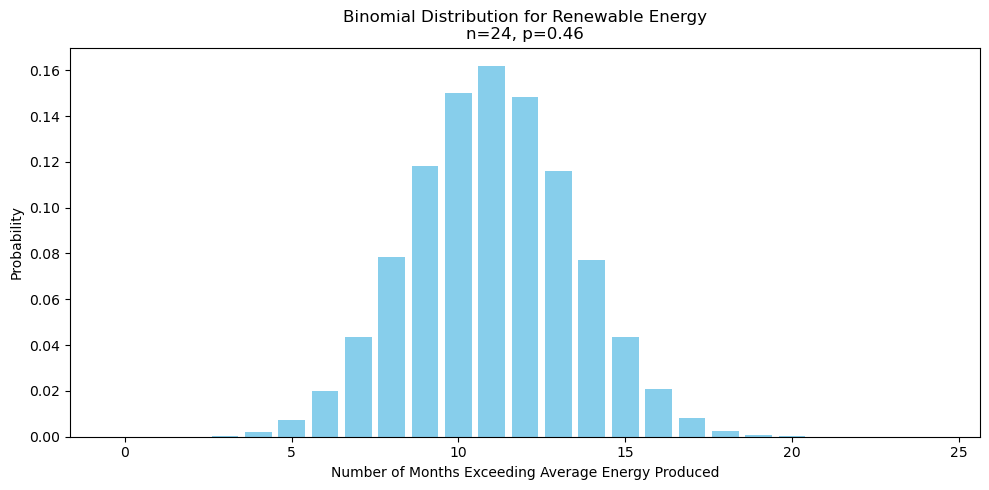

Dataframe name does not exist.


In [312]:
from scipy.stats import binom

binomial_data=ie_power_production_df['Renewable_Energy'].loc[ie_power_production_df.Year > 2022]

# Define threshold by getting the mean
threshold = binomial_data.mean()
binary_outcomes = (binomial_data > threshold).astype(int)

# Count the number of trials and successes
n = len(binary_outcomes)
successes = binary_outcomes.sum()
p = successes / n

# Simulate binomial distribution using binom.pmf funciton
x = np.arange(0, n+1)
binom_dist = binom.pmf(x, n, p)

# Show Plot
plt.figure(figsize=(10, 5))
plt.bar(x, binom_dist, color='skyblue')
plt.title(f'Binomial Distribution for Renewable Energy\nn={n}, p={p:.2f}')
plt.xlabel('Number of Months Exceeding Average Energy Produced')
plt.ylabel('Probability')
plt.tight_layout()
plt.savefig("./assests/binom.png", dpi=300, bbox_inches='tight')
plt.show()

Through binomial distribution, insight can be gained by summarizing the likelihood of successes in a fixed number of trials using the two independent outcomes (Johansen, 2024).
Thus, this graph shows the probability of renewable energy exceeding the average energy output produced. Using values from the years 2023 and 2024, which covers the 24 months of data (n) and p of 0.46, the distribution peaks at 11 months, which indicates that approximately 11 out of 24 months will deliver high renewable energy output, and a 46% chance that it will occur in any given month. Thus, we can consider that fluctuations of the outputs of renewable energy, especially with wind and solar energy, are influenced by seasonal and meteorological conditions. Grid distributors can explore other energy sources or strategies to compensate for lower energy outputs, optimizing grid stability, and improving infrastructure in regards to renewable energy.


### 2.1.4 Scatterplot with Regression Line of Renewable and Non-renewable Energy

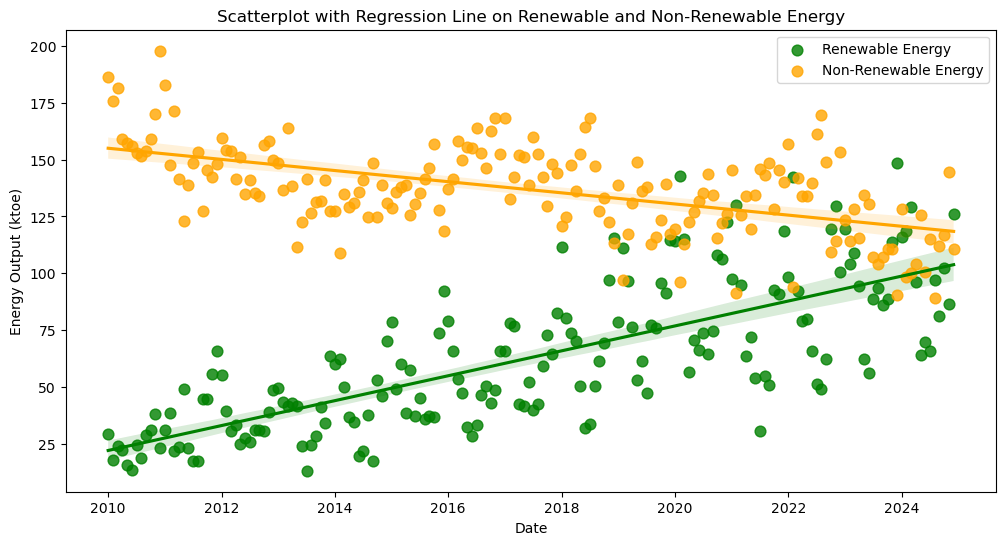

Total freed memory:40.04296875kb.


In [314]:
# Create a copy of the dataframe 
df = ie_power_production_df.copy()

# Create a numeric date index for regression
df['Date'] = df['Year'] + (df['Month_Numeric'] - 1) / 12

# Set figure size
plt.figure(figsize=(12,6))

# Renewable Energy
sns.regplot(
    x='Date',
    y='Renewable_Energy',
    data=df,
    scatter_kws={'s': 60, 'color': 'green'},
    line_kws={'color': 'green'},
    label='Renewable Energy'
)
# Non-Renewable Energy
sns.regplot(
    x='Date',
    y='Non_Renewable_Energy',
    data=df,
    scatter_kws={'s': 60, 'color': 'orange'},
    line_kws={'color': 'orange'},
    label='Non-Renewable Energy'
)
plt.title('Scatterplot with Regression Line on Renewable and Non-Renewable Energy')
plt.xlabel('Date')
plt.ylabel('Energy Output (ktoe)')
plt.legend()
#plt.savefig("./assests/scatterplots.png", dpi=300, bbox_inches='tight')
plt.show()

# Delete temporary variable to reduce storage consumption
delete_df('df')

## 2.2 Inferential Statistics

### 2.2.1 Hypothesis Testing on Target Variable

#### Custom Functions for Hypothesis Testing

In [503]:
## Check if columns are Stationary
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from scipy.stats import shapiro, kruskal, pearsonr, spearmanr, kruskal, mannwhitneyu, ttest_ind
from statsmodels.stats.diagnostic import linear_reset, acorr_breusch_godfrey
from scipy import stats

# Check if data is stationary
#Ho: The data is non stationary
#H1: Data is stationary
def adfuller_test(data):
    result=adfuller(data)
    labels = ['ADF Test Statistic','p-value','#Lags Used','Number of Observations Used']
    for value,label in zip(result,labels):
        print(label+' : '+str(f'{value:.4f}') )
    if result[1] <= 0.05:
        print("Strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary")
    else:
        print("Weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary ")
    return

# Check id data is in normal distribution
#Ho: Data is in normal distribution
#H1: Data is not in normal distribution
def shapirowilk_test(data, topic='data'):
    stat, p_value = shapiro(data)
    print(f'stats:{stat:.3f}, p_value:{p_value:.3f}')
    if p_value > 0.05:
        print(f'Fail to reject Ho, {topic} is in normal distribution.')
    else:
        print(f'Reject Ho, {topic} is in not normal distribution.')
    
    return


def seasonality_kruskal_test(y, period=12):
    y = np.array(y)
    n = len(y)

    if n < period * 2:
        print("Warning: Not enough data to assess seasonality.")
        return

    # Split y into seasonal groups
    seasonal_groups = [y[i::period] for i in range(period)]

    stat, p = kruskal(*seasonal_groups)
    print(f"Kruskal-Wallis test p-value: {p:.4f}")

    if p < 0.05:
        print("Reject H0: Evidence of seasonality (at least one group differs).")
    else:
        print("Fail to reject H0: No clear evidence of seasonality.")
    print('\n')
    
    return 

#### 1. Adfuller Test on Renewable and Non-renewable Energy
<b>Hypothesis:</b><br />
#Ho: The data is non stationary <br />
#H1: Data is stationary

In [316]:
print('Adfuller test on Non-Renewable Energy')
nonrenewable_shifted_df=ie_power_production_df['Non_Renewable_Energy'].reset_index()
nonrenewable_shifted_df['first_diff']= nonrenewable_shifted_df.Non_Renewable_Energy - nonrenewable_shifted_df.Non_Renewable_Energy.shift(12)
adfuller_test(nonrenewable_shifted_df.first_diff.dropna())

print('\n')
print('Adfuller test on Non-Renewable Energy')
renewable_energy_shifted=ie_power_production_df['Renewable_Energy'].reset_index()
renewable_energy_shifted['first_diff']= renewable_energy_shifted.Renewable_Energy - renewable_energy_shifted.Renewable_Energy.shift(12)
adfuller_test(renewable_energy_shifted.first_diff.dropna())

# Free Memory
delete_df('nonrenewable_shifted_df')
delete_df('renewable_energy_shifted')

Adfuller test on Non-Renewable Energy
ADF Test Statistic : -3.6695
p-value : 0.0046
#Lags Used : 12.0000
Number of Observations Used : 155.0000
Strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary


Adfuller test on Non-Renewable Energy
ADF Test Statistic : -5.0850
p-value : 0.0000
#Lags Used : 11.0000
Number of Observations Used : 156.0000
Strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary
Total freed memory:44.390625kb.
Total freed memory:48.73828125kb.


#### 2. Kruskal Test on Renewable and Non-renewable Energy
<b>Hypothesis:</b><br />
#Ho: There no seasonality in the data. <br />
#H1: Data exhibits seasonality.

In [148]:
print('Renewable Energy:')
seasonality_kruskal_test(ie_power_production_df.Renewable_Energy)

print('Non-renewable Energy:')
seasonality_kruskal_test(ie_power_production_df.Non_Renewable_Energy)

Renewable Energy:
Kruskal-Wallis test p-value: 0.0000
Reject H0: Evidence of seasonality (at least one group differs).


Non-renewable Energy:
Kruskal-Wallis test p-value: 0.4737
Fail to reject H0: No clear evidence of seasonality.




#### 3. Shapiro-Wilk Test (Normality)
<b>Hypothesis:</b><br />
#Ho: Data in normal distribution. <br />
#H1: Data exhibits non-normal distribution.

In [160]:
print('Renewable Energy:')
shapirowilk_test(ie_power_production_df.Renewable_Energy)

print('\n')
print('Renewable Energy Transformed:')
shapirowilk_test(ie_power_production_df.Renewable_Energy_Transformed)

print('\n')
print('Non-renewable Energy:')
shapirowilk_test(ie_power_production_df.Non_Renewable_Energy)

Renewable Energy:
stats:0.955, p_value:0.000
Reject Ho, data is in not normal distribution.


Renewable Energy Transformed:
stats:0.985, p_value:0.047
Reject Ho, data is in not normal distribution.


Non-renewable Energy:
stats:0.994, p_value:0.683
Fail to reject Ho, data is in normal distribution.


## 2.3 Comparing Countries using Hypothesis Testing

### 2.3.1 Data Preparation for European Country Comparison

#### World Population Dataset

In [497]:
world_population = pd.read_excel('./Datasets/world_population.xlsx')

world_population.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,...,107906.0,108727.0,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0,NaN
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130072080.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,...,607123269.0,623369401.0,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750503764.0,NaN
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,...,33831764.0,34700612.0,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,NaN
3,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,97630925.0,99706674.0,101854756.0,104089175.0,106388440.0,108772632.0,...,418127845.0,429454743.0,440882906.0,452195915.0,463365429.0,474569351.0,485920997.0,497387180.0,509398589.0,NaN
4,Angola,AGO,"Population, total",SP.POP.TOTL,5231654.0,5301583.0,5354310.0,5408320.0,5464187.0,5521981.0,...,28157798.0,29183070.0,30234839.0,31297155.0,32375632.0,33451132.0,34532429.0,35635029.0,36749906.0,NaN


In [499]:
try:
    world_population.drop(columns=['Country Code', 'Indicator Name', 'Indicator Code'], inplace=True)
except:
    print('Error droping columns. No changes have been made.')

countries=['Ireland', 'Finland', 'Denmark']
# Filter countries that will be used for hypothesis testing
world_population=world_population.loc[world_population['Country Name'].isin(countries)]

# Transform dataset to column countries and years to records
wp_melted = pd.melt(world_population, id_vars='Country Name', var_name='Year', value_name='Population')
wp_transformed = wp_melted.pivot(index='Year', columns='Country Name', values='Population')

# Filter records to year 2005 to 2023
wp_transformed=wp_transformed.loc[(wp_transformed.index>2004) & (wp_transformed.index<2024)]

# Delete unused dataframe 
delete_df('world_population')
delete_df('wp_melted')

# Round off to population to millions
wp_transformed=(wp_transformed/1000000).round(3)
wp_transformed


Total freed memory:1118.212890625kb.
Total freed memory:1137.384765625kb.


Country Name,Denmark,Finland,Ireland
Year,,,
2005,5.419,5.246,4.160
2006,5.437,5.266,4.274
2007,5.461,5.289,4.399
2008,5.494,5.313,4.490
2009,5.523,5.339,4.535
2010,5.548,5.363,4.560
2011,5.571,5.388,4.580
2012,5.592,5.414,4.600
2013,5.615,5.439,4.624


#### European Energy Consumption Dataset

In [487]:
# Import European Energy Consumption Dataset
european_consump_df = pd.read_csv('Datasets/final-energy-consumption-eu.csv')

european_consump_df.head()

,DATAFLOW,LAST UPDATE,freq,unit,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
0,ESTAT:SDG_07_11(1.0),27/03/25 23:00:00,A,I05,AT,2005,100.0,NaN,NaN
1,ESTAT:SDG_07_11(1.0),27/03/25 23:00:00,A,I05,AT,2006,100.3,NaN,NaN
2,ESTAT:SDG_07_11(1.0),27/03/25 23:00:00,A,I05,AT,2007,98.7,NaN,NaN
3,ESTAT:SDG_07_11(1.0),27/03/25 23:00:00,A,I05,AT,2008,98.8,NaN,NaN
4,ESTAT:SDG_07_11(1.0),27/03/25 23:00:00,A,I05,AT,2009,95.7,NaN,NaN


In [416]:
print(european_consump_df.isnull().sum())
print(f'Duplicated values: {european_consump_df.duplicated().sum()}')

DATAFLOW          0
LAST UPDATE       0
freq              0
unit              0
geo               0
TIME_PERIOD       0
OBS_VALUE         0
OBS_FLAG       1554
CONF_STATUS    1596
dtype: int64
Duplicated values: 0


In [489]:
# Country Code Mapping
country_code_dict = {
    "AT": "Austria",
    "BE": "Belgium",
    "BG": "Bulgaria",
    "CY": "Cyprus",
    "CZ": "Czech_Republic",
    "DE": "Germany",
    "DK": "Denmark",
    "EE": "Estonia",
    "EL": "Greece",
    "ES": "Spain",
    "EU27_2020": "European_Union",
    "FI": "Finland",
    "FR": "France",
    "HR": "Croatia",
    "HU": "Hungary",
    "IE": "Ireland",
    "IT": "Italy",
    "LT": "Lithuania",
    "LU": "Luxembourg",
    "LV": "Latvia",
    "MT": "Malta",
    "NL": "Netherlands",
    "PL": "Poland",
    "PT": "Portugal",
    "RO": "Romania",
    "SE": "Sweden",
    "SI": "Slovenia",
    "SK": "Slovakia"
}

try:
    # Select required features
    european_consump_df=european_consump_df[['geo','TIME_PERIOD', 'OBS_VALUE']]

    # Rename Columns
    european_consump_df.rename(columns={'geo':'country_code',
                                        'TIME_PERIOD':'year',
                                        'OBS_VALUE':'energy_consumption'}, 
                                        inplace=True)
except:
        print('Error in renaming columns. No changes have been made.')

european_consump_df['country'] = european_consump_df['country_code'].map(country_code_dict)

european_consump_pivot = european_consump_df.pivot_table(
    index='year',
    columns='country',
    values='energy_consumption',
    aggfunc='mean'
)

# Delete unused dataframe to free up memory
delete_df('european_consump_df')

european_consump_pivot.head()

Total freed memory:1095.619140625kb.


country,Austria,Belgium,Bulgaria,Croatia,Cyprus,Czech_Republic,Denmark,Estonia,European_Union,Finland,...,Luxembourg,Malta,Netherlands,Poland,Portugal,Romania,Slovakia,Slovenia,Spain,Sweden
year,,,,,,,,,,,,,,,,,,,,,
2005,43.166667,46.256667,37.026667,36.326667,34.760000,42.556667,39.453333,35.003333,373.180000,43.02,...,38.043333,33.880000,51.940000,53.103333,40.270000,41.603333,37.446667,35.886667,66.373333,45.326667
2006,43.296667,45.670000,38.310000,36.393333,35.363333,43.030000,39.893333,35.246667,374.880000,45.26,...,37.410000,34.020000,51.803333,55.426667,39.693333,42.010000,36.430000,35.816667,64.876667,45.356667
2007,42.610000,44.226667,37.806667,36.530000,36.506667,42.106667,39.993333,37.733333,368.430000,45.46,...,36.780000,35.026667,50.883333,55.596667,40.166667,40.873333,36.700000,35.983333,66.683333,45.450000
2008,42.640000,46.133333,37.136667,37.106667,37.406667,42.100000,39.510000,37.430000,371.970000,43.83,...,37.086667,36.540000,51.830000,56.606667,39.083333,42.256667,38.023333,38.473333,64.346667,44.653333
2009,41.306667,44.723333,32.550000,35.990000,36.700000,40.703333,37.660000,33.790000,354.063333,41.02,...,34.466667,33.030000,49.953333,56.066667,38.610000,38.493333,34.800000,34.026667,59.896667,43.376667


### 2.3.2 Hypothesis Testing Comparing European Countries on Energy Consumption 

Statement: Based on the latest population count in European countries, Ireland, Denmark, and Finland have comparable population sizes of 5.3M, 6.0M, and 5.6M, respectively (Worldometer, 2025). Using hypothesis testing, we can assess whether there is a similar pattern in energy consumption among these countries

In [421]:
# Set variables to use for testing
ie = european_consump_pivot['Ireland']
dk = european_consump_pivot['Denmark']
fi = european_consump_pivot['Finland']

# Delete unused dataframe to free up memory
delete_df('european_consump_pivot')

Total freed memory:838.19921875kb.


#### Custom Functions

In [523]:
# Define a function to test using pearson correlation
def person_correlation(consumption):
    coef, p_value = pearsonr(wp_transformed[consumption.name], consumption)

    print(f"Checking the correlation of {consumption.name}'s population and energy consumption.")
    print(f"corr_coed:{coef:.3f}, p_value:{p_value:.3f}")
    
    if p_value < 0.05:
        print("Reject the null hypothesis: There is a significant linear correlation.")
    else:
        print("Fail to reject the null hypothesis: No significant linear correlation.")

    plt.figure(figsize=(8, 6))
    sns.regplot(x=wp_transformed[consumption.name], y=ie, color='green', line_kws={"color": "red"})
    plt.title(f"Correlation Plot of {consumption.name}'s Population vs. Energy Consumption")
    plt.xlabel('Population')
    plt.ylabel('Energy Consumption')
    plt.grid(True)
    #export_graph(f'corr_{consumption.name}')
    plt.tight_layout()
    plt.show()

# Define function to do hypothesis testing using Shapiro
def comparing_eu_shapiro(data):
    country=data.name
    print(f"Shapiro-wilk test on {country}'s energy consumption.")
    shapirowilk_test(data, topic=f"{country}'s energy consumption")
    plt.figure(figsize=(8,6))
    sns.histplot(data, bins=10, kde=True, color='green')
    plt.title(f'Shapiro-Wilk Test on Energy Consumption in {country}')
    #export_graph(f'{country}_shap')
    plt.show()


#### 1. Shapiro-Wilk Test on Energy Consumption in Ireland and Denmark

Shapiro-wilk test on Ireland's energy consumption.
stats:0.934, p_value:0.204
Fail to reject Ho, Ireland's energy consumption is in normal distribution.


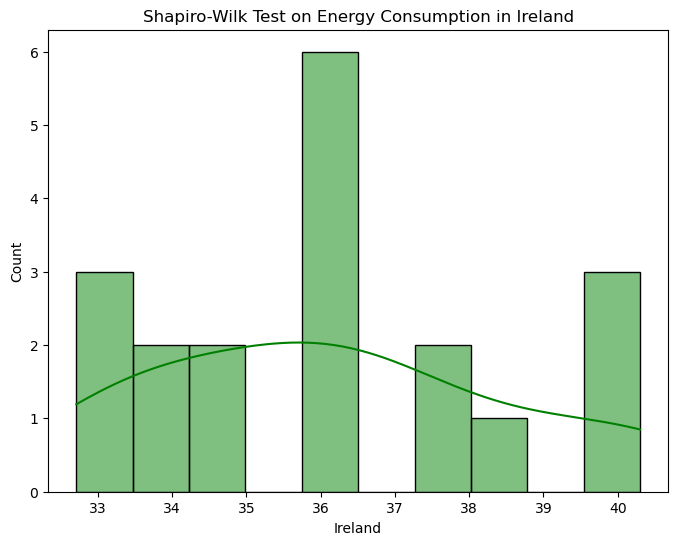

Shapiro-wilk test on Denmark's energy consumption.
stats:0.943, p_value:0.294
Fail to reject Ho, Denmark's energy consumption is in normal distribution.


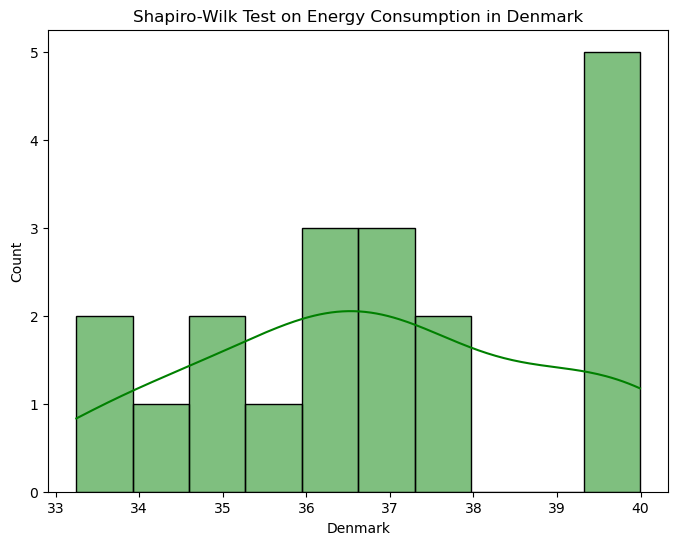

Shapiro-wilk test on Finland's energy consumption.
stats:0.962, p_value:0.614
Fail to reject Ho, Finland's energy consumption is in normal distribution.


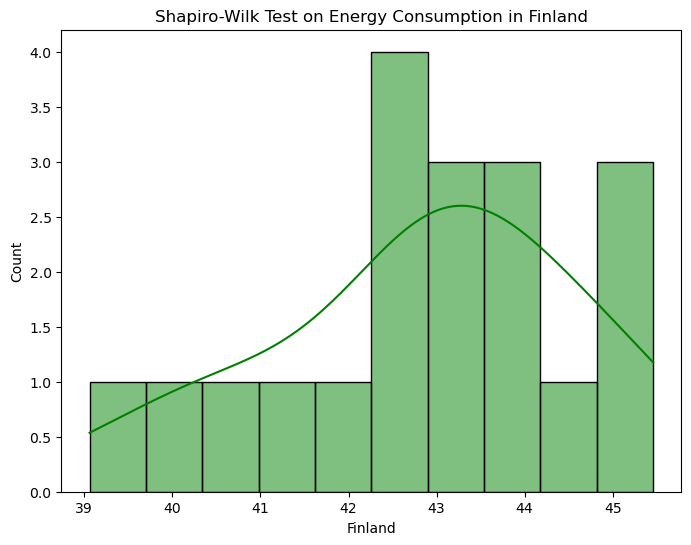

In [399]:
# Hypotheses:
# Ho: Energy consumption is in a normal distribution
# H1: Energy consumption is not in normal distribution
for country in [ie, dk, fi]:
    comparing_eu_shapiro(country)

Based on the result, Ireland, Finland, and Denmark's energy consumption data are in normal distribution, having a p-value of 0.204, 0.614, and 0.294, respectively. Therefore, the energy consumption values in these countries are close to the average, which also indicates a stable usage of power. Since these datasets are in normal distribution, we can further employ some parametric tests for hypothesis testing.

3. T-test for Ireland and Denmark on Energy Consumption
t-stats:-0.91, p-value: 0.37
-> Fail to reject the null hypothesis: There is no significant difference in the average energy consumption between Ireland and Denmark


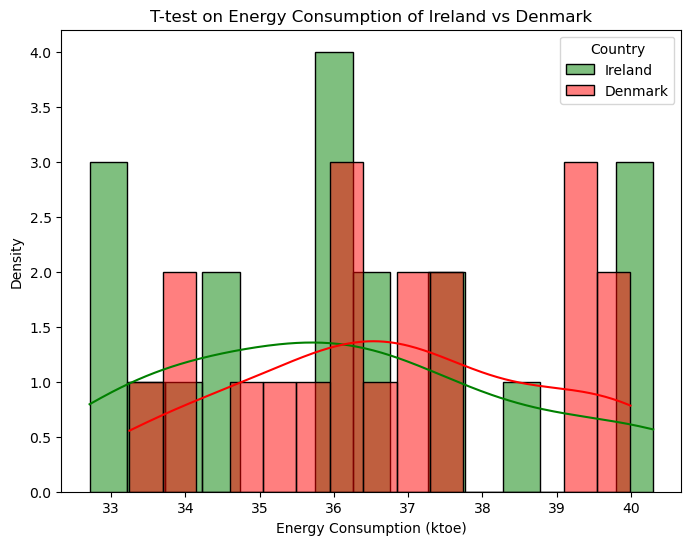

In [354]:
# 2. T-test for Ireland and Denmark on Energy Consumption
# Ho: The average energy consumption is equal between Ireland and other European countries.
# H1: The average energy consumption in Ireland differs from Denmark.  
t_stat, p_val = ttest_ind(ie, dk)

print('3. T-test for Ireland and Denmark on Energy Consumption')
print(f't-stats:{t_stat:.2f}, p-value: {p_val:.2f}')
if p_val < 0.05:
    print("-> Reject the null hypothesis: There is a significant difference in the average energy consumption between Ireland and Denmark.")
else:
    print("-> Fail to reject the null hypothesis: There is no significant difference in the average energy consumption between Ireland and Denmark")

plt.figure(figsize=(8, 6))
sns.histplot(ie, kde=True, label='Ireland', bins=15, color='green')
sns.histplot(dk, kde=True, label='Denmark', bins=15, color='red')
plt.xlabel("Energy Consumption (ktoe)")
plt.ylabel("Density")
plt.title('T-test on Energy Consumption of Ireland vs Denmark')
plt.legend(title="Country")
#export_graph('Ttest_eu')
plt.show()

Checking the correlation of Ireland's population and energy consumption
corr_coed:-0.340, p_value:0.155
Fail to reject the null hypothesis: No significant linear correlation.
Graph exported.


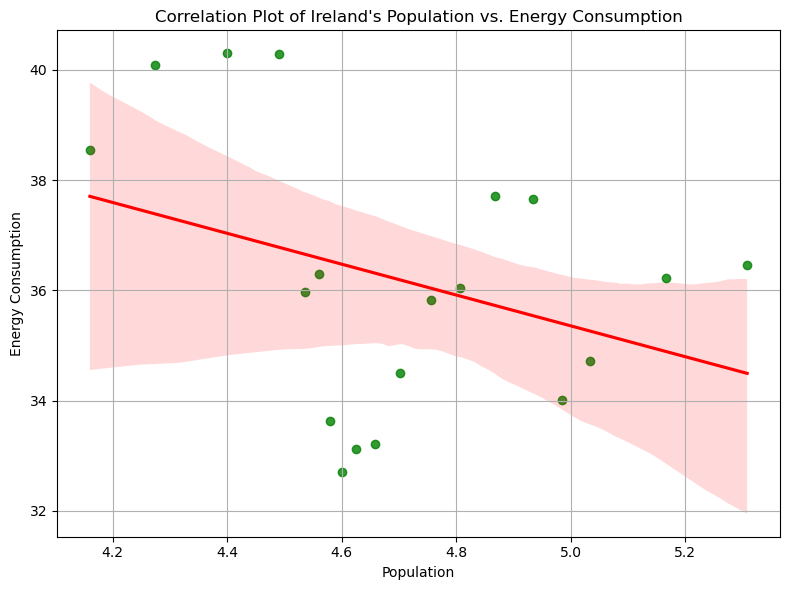

Checking the correlation of Finland's population and energy consumption
corr_coed:-0.539, p_value:0.017
Reject the null hypothesis: There is a significant linear correlation.
Graph exported.


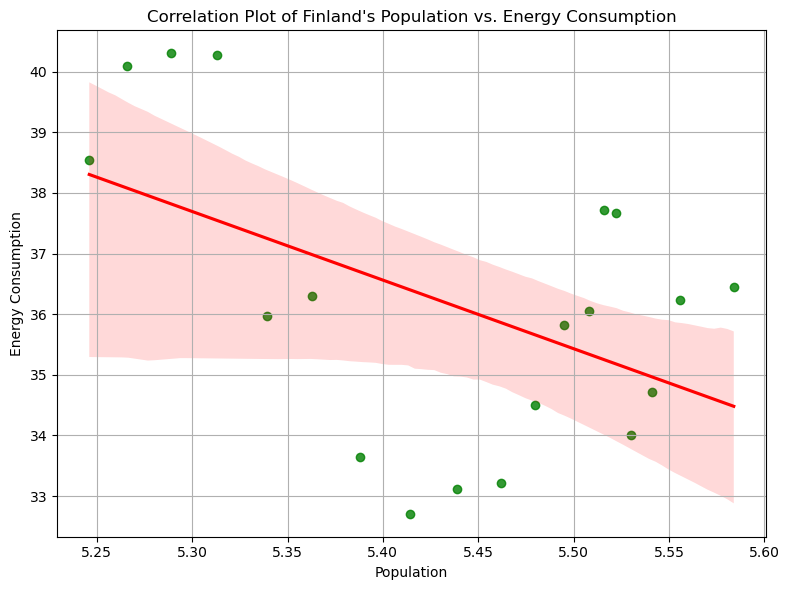

Checking the correlation of Denmark's population and energy consumption
corr_coed:-0.842, p_value:0.000
Reject the null hypothesis: There is a significant linear correlation.
Graph exported.


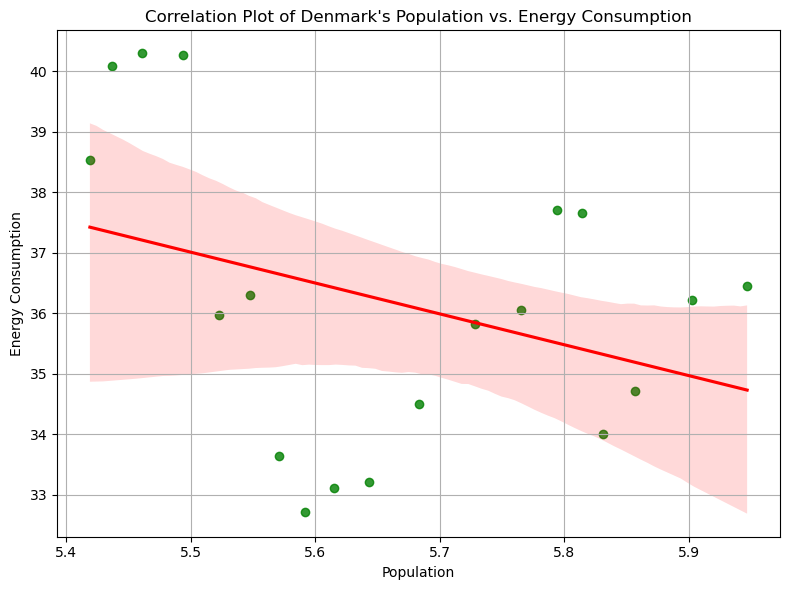

In [521]:
# 3. Pearson Correlation on population and energy consumption
# Ho: There is no significant linear correlation between population and energy consumption.
# H1:  There is significant evidence of a linear correlation between population and energy consumption.
person_correlation(ie)
person_correlation(fi)
person_correlation(dk)

Reject the null hypothesis: There is a significant difference between the means of the groups.
F-statistic: 57.215517289363156
p-value: 4.583891986094953e-14


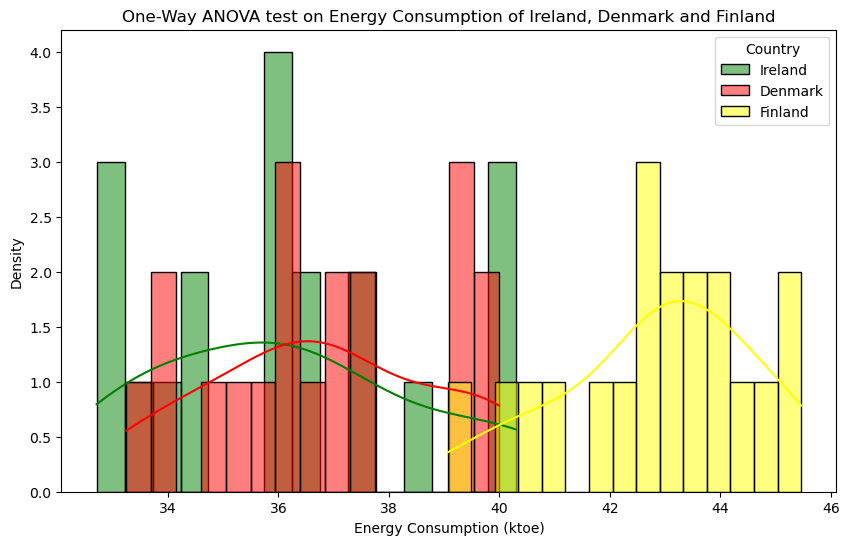

In [530]:
# 4. Perform One-Way ANOVA
f_stat, p_value = stats.f_oneway(ie, fi, dk)

# Set significance level (alpha)
alpha = 0.05

# Compare p-value with significance level to make a decision
if p_value <= alpha:
    result = f"Reject the null hypothesis: There is a significant difference between the means of the groups.\nF-statistic: {f_stat}\np-value: {p_value}"
else:
    result = f"Fail to reject the null hypothesis: There is no significant difference between the means of the groups.\nF-statistic: {f_stat}\np-value: {p_value}"

# Display the decision
print(result)
plt.figure(figsize=(10, 6))
sns.histplot(ie, kde=True, label='Ireland', bins=15, color='green')
sns.histplot(dk, kde=True, label='Denmark', bins=15, color='red')
sns.histplot(fi, kde=True, label='Finland', bins=15, color='yellow')
plt.xlabel("Energy Consumption (ktoe)")
plt.ylabel("Density")
plt.title('One-Way ANOVA test on Energy Consumption of Ireland, Denmark and Finland')
plt.legend(title="Country")
#export_graph('anova_test')
plt.show()

# 3. Machine Learning

## 3.1 Forecasting using Artificial Neural Networks

In [127]:
# Import Libraries
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input
from keras.callbacks import EarlyStopping
from keras.metrics import RootMeanSquaredError, MeanAbsoluteError
import tensorflow as tf
import random

# Set seed to tensorflow to avoid unstable results for ANN
seed=0
tf.random.set_seed(seed)
np.random.seed(seed)
random.seed(seed)

### 3.1.1 Train and Test Split

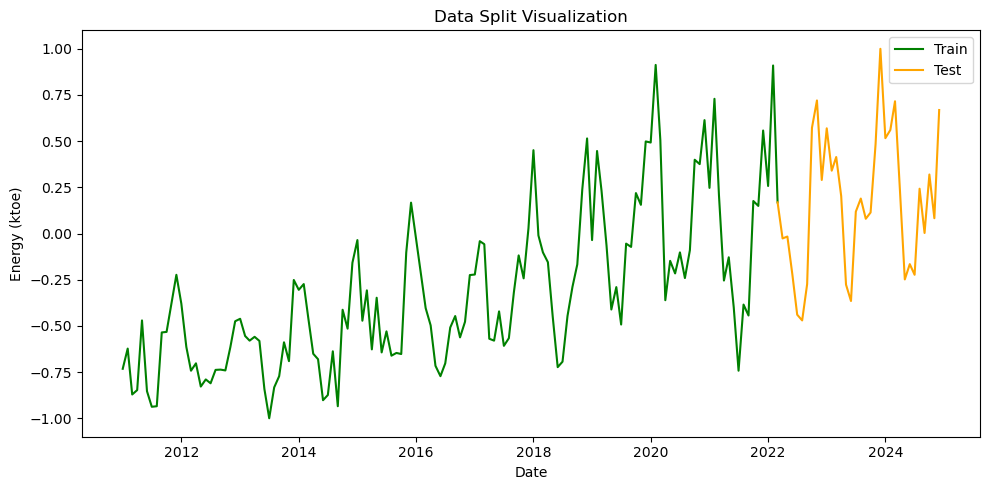

In [130]:
# Add Lag Values
#modeling_data_features=add_features(ie_power_production_df[['Year', 'Month_Numeric', 'Renewable_Energy']])
modeling_data_lags = generate_lag_features(ie_power_production_df['Renewable_Energy'], 12)

#modeling_data_features = modeling_data_features.drop(columns=['Renewable_Energy'])
#modeling_data = modeling_data_lags.join(modeling_data_features, how='left')

scaler = MinMaxScaler(feature_range=(-1, 1))
scaled = scaler.fit_transform(modeling_data_lags)

X = scaled[:, 1:]  # Lag features
y = scaled[:, 0]   # Target Value : Renewable Energy

split_idx = int(len(X) * 0.80)
X_train, X_test = X[:split_idx+1], X[split_idx:]
y_train, y_test = y[:split_idx+1], y[split_idx:]

# Set figure size
plt.figure(figsize=(10, 5))  

# Plot Train and Test data
sns.lineplot(x=modeling_data_lags.index[0:len(y_train)], y=y_train, label='Train', color='green')
sns.lineplot(x=modeling_data_lags.index[len(y_train)-1:len(y_train)+len(y_test)], y=y_test, label='Test', color='orange')
plt.title(f"Data Split Visualization")
plt.xlabel('Date')
plt.ylabel('Energy (ktoe)')
plt.legend()
plt.tight_layout()
plt.show()


### 3.1.2 Model Training 

Epoch 1/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 636us/step - loss: 0.1750 - r2_score: -4.5832     
Epoch 2/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 601us/step - loss: 0.1000 - r2_score: -2.1273  
Epoch 3/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 605us/step - loss: 0.0600 - r2_score: -0.4040  
Epoch 4/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 589us/step - loss: 0.0401 - r2_score: 0.2551   
Epoch 5/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 584us/step - loss: 0.0437 - r2_score: 0.1650   
Epoch 6/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 632us/step - loss: 0.0516 - r2_score: 0.0672       
Epoch 6: early stopping
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
R2 score for train 0.69 and test 0.57.


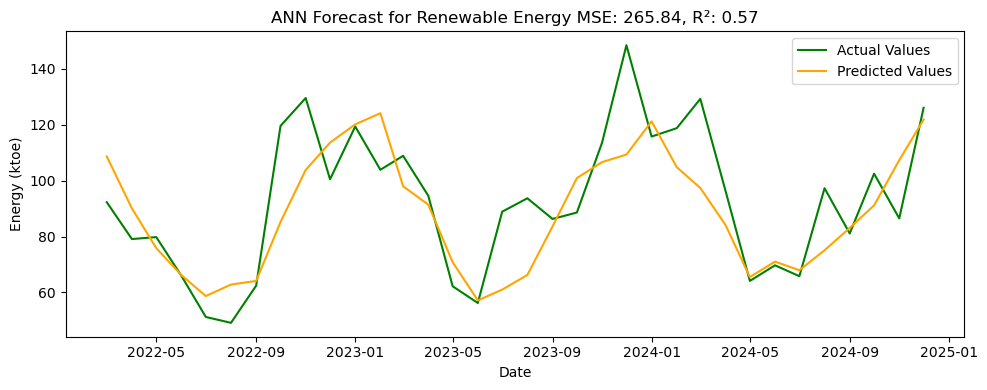

In [133]:
# Initialize ANN Model using Sequential
ann_model=Sequential()
ann_model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
ann_model.add(Dropout(0.3))  # Dropout to reduce overfitting
ann_model.add(Dense(32, activation='relu'))
ann_model.add(Dense(1))
ann_model.compile(loss='mean_squared_error', optimizer='adam', metrics = ['r2_score'])
early_stop = EarlyStopping(monitor='loss', patience=2, verbose=1)

# Train the Model
history = ann_model.fit(X_train, y_train, epochs=100, batch_size=1, verbose=1, callbacks=[early_stop], shuffle=False)

# Get Predictions for Train and Test
ann_y_test_pred = ann_model.predict(X_test)
ann_y_train_pred = ann_model.predict(X_train)

# Get score metrics
r2_train, mse_train=calculate_metrics(y_train, ann_y_train_pred)
r2_test, mse_test=calculate_metrics(y_test, ann_y_test_pred)
print(f'R2 score for train {r2_train:.2f} and test {r2_test:.2f}.')

# Inverse scale results
y_pred = scaler.inverse_transform(np.hstack([ann_y_test_pred.reshape(-1, 1), X_test]))[:, 0]
y_test_actual = scaler.inverse_transform(np.hstack([y_test.reshape(-1, 1), X_test]))[:, 0]

# Recalculate the actual prediction score
r2_pred, mse_pred = calculate_metrics(y_test_actual, y_pred)

# Plot results
plt.figure(figsize=(10, 4))
sns.lineplot(x=ie_power_production_df.index[-len(y_test):], y=y_test_actual, label='Actual Values', color='green')
sns.lineplot(x=ie_power_production_df.index[-len(y_test):], y=y_pred, label='Predicted Values', color='orange')
plt.title(f"ANN Forecast for Renewable Energy MSE: {mse_pred:.2f}, R²: {r2_pred:.2f}")
plt.xlabel('Date')
plt.ylabel('Energy (ktoe)')
plt.legend()
plt.tight_layout()
plt.show()


## 3.2 Seasonal AutoRegressive Integrated Moving Average (SARIMA)

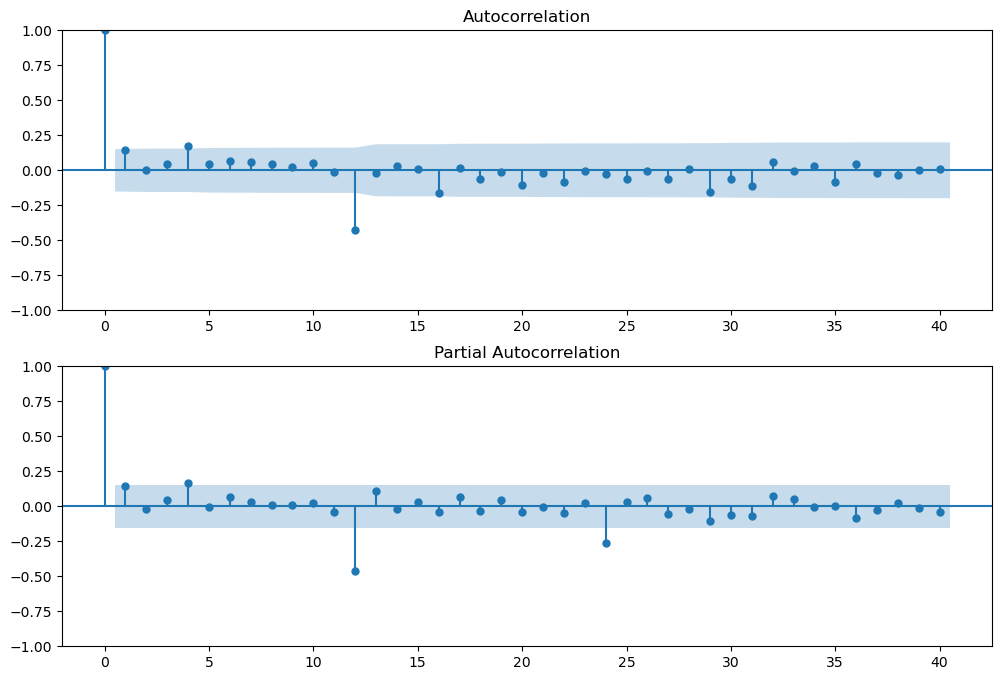

In [136]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
import statsmodels.api as sm

plt.style.use('default')

fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(renewable_energy_shifted.first_diff.iloc[13:],lags=40,ax=ax1)
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(renewable_energy_shifted.first_diff.iloc[13:],lags=40,ax=ax2)

plt.show()

### 3.2.2 Train Test Split

In [139]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
sarima_data=ie_power_production_df['Renewable_Energy'].reset_index().set_index('Date')

# Train-test split
split_idx = int(len(sarima_data) * 0.8)
train = sarima_data['Renewable_Energy'][:split_idx]
test = sarima_data['Renewable_Energy'][split_idx:]
train.shape, test.shape


((144,), (36,))

### 3.2.3 Get the Best (p,d,q) values using PMD Arima 

In [142]:
import pmdarima as pm

model = pm.auto_arima(
    train,
    start_p=0, 
    start_q=0,
    max_p=2, 
    max_q=2,
    start_P=0, 
    start_Q=0,
    max_P=2, 
    max_Q=2,
    seasonal=True,
    m=12,  # seasonal period
    d=None,
    D=None,          
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True,           
    n_fits=50               
)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=1220.889, Time=0.05 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=1203.499, Time=0.11 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=1210.485, Time=0.17 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=1219.079, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=1219.507, Time=0.03 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=1189.954, Time=0.80 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=1185.053, Time=0.61 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=1185.799, Time=0.16 sec
 ARIMA(1,1,0)(2,0,2)[12] intercept   : AIC=1185.944, Time=0.91 sec
 ARIMA(1,1,0)(1,0,2)[12] intercept   : AIC=1184.017, Time=0.93 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : AIC=1203.544, Time=0.34 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=1210.671, Time=0.15 sec
 ARIMA(0,1,0)(1,0,2)[12] intercept   : AIC=1202.016, Time=0.56 sec
 ARIMA(2,1,0)(1,0,2)[12] intercept   : AIC=1178.743, Time=0.84 sec
 ARIMA(2,1,0)(0,0,2

### 3.2.4 Train Model

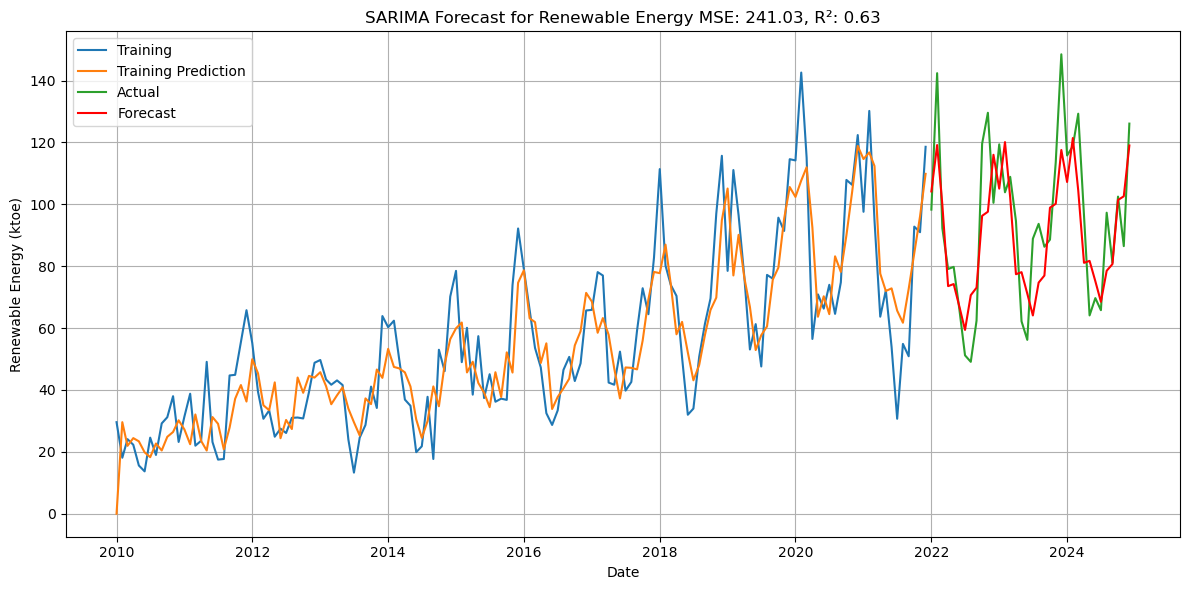

R2 score for train 0.78 and test 0.63.


In [144]:
# Fit SARIMA
model = SARIMAX(train, order=(1,1,1), seasonal_order=(1, 0, 1, 12))
results = model.fit(disp=False)

# Forecast
forecast = results.get_forecast(steps=len(test))
mean_forecast = forecast.predicted_mean
conf_int = forecast.conf_int()

# Result for train
train_pred = results.fittedvalues

# Calculate R2 score for train and 
train_r2, train_mse = calculate_metrics(train[1:], train_pred[1:])
test_r2, test_mse = calculate_metrics(test, mean_forecast)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training')
plt.plot(train.index, train_pred, label='Training Prediction')
plt.plot(test.index, test, label='Actual')
plt.plot(mean_forecast.index, mean_forecast, label='Forecast', color='red')
plt.title(f"SARIMA Forecast for Renewable Energy MSE: {test_mse:.2f}, R²: {test_r2:.2f}")
plt.xlabel("Date")
plt.ylabel("Renewable Energy (ktoe)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f'R2 score for train {train_r2:.2f} and test {test_r2:.2f}.')

# References

Kruskal Test: <br />
Bhattacharjee, A. (2021) Kruskal-Wallis Test: A powerful tool for detecting seasonality in time series data using Python. Medium. Available at: https://medium.com/@avijit.bhattacharjee1996/kruskal-wallis-test-a-powerful-tool-for-detecting-seasonality-in-time-series-data-using-python-d827ef23d29e (Accessed: 7 May 2025).

Pearsons Test:<br />
SciPy, 2022. scipy.stats.pearsonr — SciPy v1.9.3 Manual. [online] Available at: https://docs.scipy.org/doc/scipy-1.9.3/reference/generated/scipy.stats.pearsonr.html [Accessed 8 May 2025].